# 🤝 5-Fold Multimodal Video + Audio Late Fusion Evaluation Pipeline
### 🏆 Gemastik 2026 Revision 1 Pipeline

This notebook evaluates the 5-Fold fine-tuned **Video ViT (`dima806`)** and **Audio Wav2Vec2 (`MelodyMachine`)** fold models — Video loaded from `models/revision1/`, Audio v2 loaded from `models/revision1_v2/` — using a **50/50 Late Fusion Scheme** ($0.5 \cdot P_{\text{video}} + 0.5 \cdot P_{\text{audio}}$).

### 🔑 Key Methodological Features:
1. **Strict 5-Fold Split Loading (`kfold_splits.json`):** Evaluates exact 5-fold validation splits generated by `generate_kfold_split.ipynb`.
2. **50/50 Multimodal Late Fusion:** Combines Video and Audio probabilities ($P_{\text{multimodal}} = 0.5 \cdot P_{\text{video}} + 0.5 \cdot P_{\text{audio}}$).
3. **5-Fold Cross-Validation Metrics:** Reports 5-Fold Mean $\pm$ Std (Accuracy, Precision, Recall, Macro F1-Score) + Master Out-of-Fold Confusion Matrix.
4. **Independent Held-Out Test Evaluation (Section 10):** Evaluates 5-Fold Multimodal Soft Voting Ensemble on dedicated test archives (`testReal.zip` & `testAI.zip`).

In [1]:
# 1. Setup Environment & Import Libraries
import os
import glob
import shutil
import random
import zipfile
import subprocess
import json
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import librosa
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from transformers import AutoImageProcessor, AutoModelForImageClassification, AutoFeatureExtractor, AutoModelForAudioClassification

# Set seeds for 100% reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Optional: Mount Google Drive if in Google Colab
try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("✅ Google Drive mounted.")
except Exception:
    print("ℹ️ Not running on Google Colab or Drive already mounted.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Execution Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 Active GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB VRAM)")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted.
🖥️ Execution Device: cuda
🎮 Active GPU: Tesla T4 (15.64 GB VRAM)


In [2]:
# 2. Setup Base Directory & Drive Paths
DRIVE_DATASET_DIR = "/content/drive/MyDrive/Gemastik26/Dataset Indonesia"
MODEL_SAVE_DIR = "/content/drive/MyDrive/Gemastik26/models/revision1"
AUDIO_MODEL_SAVE_DIR = "/content/drive/MyDrive/Gemastik26/models/revision1_v2"  # v2 audio checkpoints (kfold_audio_ai_detection_v2.ipynb)
KFOLD_SPLIT_FILE = "/content/drive/MyDrive/Gemastik26/kfold_splits.json"

LOCAL_RAW_DIR = "/content/dataset_raw"
LOCAL_FRAMES_DIR = "/content/dataset_frames_1fps"
LOCAL_AUDIO_DIR = "/content/dataset_audio_16k"
CLASSES = ["Real", "AI"]
DISPLAY_LABELS = ["Asli", "AI-Generated"]  # Label Indonesia untuk confusion matrix (0=Real/Asli, 1=AI/AI-Generated)
SAMPLE_RATE = 16000
MAX_AUDIO_SAMPLES = int(SAMPLE_RATE * 5.0)  # 5.0 seconds = 80,000 samples

print(f"📁 Video Model Save Directory: {MODEL_SAVE_DIR}")
print(f"🎙️ Audio Model Save Directory: {AUDIO_MODEL_SAVE_DIR}")
print(f"🛡️ 5-Fold Split File: {KFOLD_SPLIT_FILE}")


📁 Video Model Save Directory: /content/drive/MyDrive/Gemastik26/models/revision1
🎙️ Audio Model Save Directory: /content/drive/MyDrive/Gemastik26/models/revision1_v2
🛡️ 5-Fold Split File: /content/drive/MyDrive/Gemastik26/kfold_splits.json


In [3]:
# 3. Unzip Raw Dataset Archives & Extract Audio & Frames
ZIP_PATHS = {
    "Real": [
        os.path.join(DRIVE_DATASET_DIR, "Real", "train.zip"),
        os.path.join(DRIVE_DATASET_DIR, "train.zip")
    ],
    "AI": [
        os.path.join(DRIVE_DATASET_DIR, "AI", "trainAI.zip"),
        os.path.join(DRIVE_DATASET_DIR, "trainAI.zip")
    ]
}

def unzip_file(zip_path, extract_to):
    print(f"📦 Unzipping '{zip_path}' -> '{extract_to}'...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"✅ Unzipped successfully to {extract_to}")

for cls, candidates in ZIP_PATHS.items():
    target_dir = os.path.join(LOCAL_RAW_DIR, cls)
    if os.path.exists(target_dir) and len(os.listdir(target_dir)) > 0:
        print(f"⏭️ Target directory '{target_dir}' already exists. Skipping unzip.")
        continue
    found_zip = None
    for p in candidates:
        if os.path.exists(p):
            found_zip = p
            break
    if found_zip:
        unzip_file(found_zip, target_dir)
    else:
        print(f"⚠️ Zip file not found for {cls} at candidates: {candidates}")


⏭️ Target directory '/content/dataset_raw/Real' already exists. Skipping unzip.
📦 Unzipping '/content/drive/MyDrive/Gemastik26/Dataset Indonesia/AI/trainAI.zip' -> '/content/dataset_raw/AI'...
✅ Unzipped successfully to /content/dataset_raw/AI


In [4]:
# 4. 🛡️ STRICT 5-FOLD SPLIT LOADING (Must be generated by generate_kfold_split.ipynb)
if os.path.exists(KFOLD_SPLIT_FILE):
    with open(KFOLD_SPLIT_FILE, "r", encoding="utf-8") as f:
        kfold_splits = json.load(f)
    print(f"✅ LOADED 5-FOLD SPLIT DICTIONARY FROM DRIVE:")
    print(f"➡️ {KFOLD_SPLIT_FILE}")
else:
    raise FileNotFoundError(
        f"❌ ERROR: 5-Fold split file not found at: {KFOLD_SPLIT_FILE}\n"
        f"Please execute 'generate_kfold_split.ipynb' first to generate and export kfold_splits.json to Drive!"
    )

print(f"📊 Active Folds Loaded: {list(kfold_splits.keys())}")
for f_name, f_data in kfold_splits.items():
    print(f"   - {f_name}: {len(f_data['train_stems'])} Train Stems | {len(f_data['val_stems'])} Val Stems")


✅ LOADED 5-FOLD SPLIT DICTIONARY FROM DRIVE:
➡️ /content/drive/MyDrive/Gemastik26/kfold_splits.json
📊 Active Folds Loaded: ['fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5']
   - fold_1: 853 Train Stems | 214 Val Stems
   - fold_2: 854 Train Stems | 213 Val Stems
   - fold_3: 853 Train Stems | 214 Val Stems
   - fold_4: 854 Train Stems | 213 Val Stems
   - fold_5: 854 Train Stems | 213 Val Stems


In [5]:
# 5. Extract Video Frames (1 FPS) & Audio Tracks (16kHz Mono) for All Dataset Videos
def extract_audio_from_video(video_path, output_wav_path, target_sr=16000):
    cmd = [
        "ffmpeg", "-y", "-i", video_path, "-vn",
        "-acodec", "pcm_s16le", "-ar", str(target_sr), "-ac", "1",
        output_wav_path
    ]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    if not os.path.exists(output_wav_path) or os.path.getsize(output_wav_path) < 100:
        try:
            y, sr = librosa.load(video_path, sr=target_sr, mono=True)
            sf.write(output_wav_path, y, target_sr)
        except Exception:
            pass

def extract_frames_from_video(video_path, target_fps=1.0, max_frames=30):
    # FFMPEG FIRST: reliable decoding + true-RGB JPEGs (matches the video-notebook frames the
    # model works on). cv2 can misdecode some videos in this environment (wrong resolution).
    frames = []
    temp_dir = f"/content/ffmpeg_frames_{Path(video_path).stem}_{os.getpid()}"
    os.makedirs(temp_dir, exist_ok=True)
    pattern = os.path.join(temp_dir, "frame_%04d.jpg")
    cmd = [
        "ffmpeg", "-y", "-i", video_path,
        "-vf", f"fps={target_fps}", "-frames:v", str(max_frames),
        pattern
    ]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    for jp in sorted(glob.glob(os.path.join(temp_dir, "*.jpg"))):
        try:
            frames.append(Image.open(jp).convert("RGB"))
        except Exception:
            pass
        if len(frames) >= max_frames:
            break
    shutil.rmtree(temp_dir, ignore_errors=True)
    if not frames:
        # cv2 fallback (only if ffmpeg failed)
        cap = cv2.VideoCapture(video_path)
        count = 0
        if cap.isOpened():
            video_fps = cap.get(cv2.CAP_PROP_FPS)
            if video_fps <= 0 or np.isnan(video_fps):
                video_fps = 30.0
            frame_interval = max(1, int(round(video_fps / target_fps)))
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break
                if count % frame_interval == 0:
                    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    frames.append(Image.fromarray(frame_rgb))
                    if len(frames) >= max_frames:
                        break
                count += 1
            cap.release()
    return frames

# Pre-extract audio files into LOCAL_AUDIO_DIR
for cls in CLASSES:
    cls_raw_dir = os.path.join(LOCAL_RAW_DIR, cls)
    cls_audio_dir = os.path.join(LOCAL_AUDIO_DIR, cls)
    os.makedirs(cls_audio_dir, exist_ok=True)
    if not os.path.exists(cls_raw_dir):
        continue
    video_files = glob.glob(os.path.join(cls_raw_dir, "**", "*.mp4"), recursive=True)
    print(f"🎙️ Processing 16kHz audio for {len(video_files)} {cls} videos...")
    for vid in tqdm(video_files, desc=f"Audio Extraction [{cls}]"):
        v_stem = Path(vid).stem
        out_wav = os.path.join(cls_audio_dir, f"{v_stem}.wav")
        if not os.path.exists(out_wav) or os.path.getsize(out_wav) < 100:
            extract_audio_from_video(vid, out_wav, target_sr=SAMPLE_RATE)

print("✅ Video & Audio Extraction Helpers Ready!")


🎙️ Processing 16kHz audio for 82 Real videos...


Audio Extraction [Real]: 100%|██████████| 82/82 [00:26<00:00,  3.06it/s]


🎙️ Processing 16kHz audio for 413 AI videos...


Audio Extraction [AI]:   9%|▉         | 38/413 [00:09<01:34,  3.97it/s]


KeyboardInterrupt: 

In [ ]:
# 6. Define Feature Processors & Transforms
video_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # dima806 processor & training use mean=std=0.5 (NOT ImageNet)
])

feature_extractor = AutoFeatureExtractor.from_pretrained("MelodyMachine/Deepfake-audio-detection-V2")
print("✅ Loaded Video Transforms & Audio Feature Extractor!")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


✅ Loaded Video Transforms & Audio Feature Extractor!


In [ ]:
# 7. Single Video Modality Predictor Helpers (Memory Optimized)
def predict_video_ai_prob(video_path, video_model, batch_size=16):
    frames = extract_frames_from_video(video_path, target_fps=1.0, max_frames=30)
    if not frames:
        print(f"⚠️ WARNING: Could not extract any frames from video (OpenCV + ffmpeg failed): {video_path}")
        return 0.5  # Neutral fallback
    all_probs = []
    for i in range(0, len(frames), batch_size):
        batch_frames = frames[i:i + batch_size]
        tensors = torch.stack([video_transform(f) for f in batch_frames]).to(device)
        with torch.no_grad():
            with torch.amp.autocast("cuda"):
                outputs = video_model(tensors)
                logits = outputs.logits if hasattr(outputs, 'logits') else outputs
                probs = F.softmax(logits, dim=-1).cpu().numpy()
        all_probs.extend(probs[:, 1])  # Index 1 = AI for Video ViT model
        del tensors
        torch.cuda.empty_cache()
    return float(np.mean(all_probs))

def predict_audio_ai_prob(audio_wav_path, audio_model):
    if not os.path.exists(audio_wav_path) or os.path.getsize(audio_wav_path) < 100:
        return 0.5  # Neutral fallback
    try:
        waveform = None
        try:
            waveform, sr = torchaudio.load(audio_wav_path)
        except Exception:
            y, sr = librosa.load(audio_wav_path, sr=SAMPLE_RATE, mono=True)
            waveform = torch.from_numpy(y).unsqueeze(0)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
        if sr != SAMPLE_RATE:
            resampler = T.Resample(sr, SAMPLE_RATE)
            waveform = resampler(waveform)
        total_len = waveform.shape[-1]
        chunks = []
        if total_len <= MAX_AUDIO_SAMPLES:
            pad_len = MAX_AUDIO_SAMPLES - total_len
            chunks.append(F.pad(waveform, (0, pad_len)))
        else:
            # 100% coverage: include + pad the partial tail chunk instead of dropping it
            for start in range(0, total_len, MAX_AUDIO_SAMPLES):
                chunk = waveform[:, start:start + MAX_AUDIO_SAMPLES]
                if chunk.shape[-1] < MAX_AUDIO_SAMPLES:
                    chunk = F.pad(chunk, (0, MAX_AUDIO_SAMPLES - chunk.shape[-1]))
                chunks.append(chunk)
        inputs_list = [feature_extractor(c.squeeze(0).numpy(), sampling_rate=SAMPLE_RATE, do_normalize=True, return_tensors="pt").input_values.squeeze(0) for c in chunks]
        chunk_ai_probs = []
        with torch.no_grad():
            # Sub-batch chunks (<=8) so long videos cannot OOM the GPU mid-stack
            for i in range(0, len(inputs_list), 8):
                tensors = torch.stack(inputs_list[i:i + 8]).to(device)
                with torch.amp.autocast("cuda"):
                    outputs = audio_model(tensors)
                    logits = outputs.logits if hasattr(outputs, 'logits') else outputs
                    probs = F.softmax(logits, dim=-1).cpu().numpy()
                chunk_ai_probs.append(probs[:, 0])  # Note: Index 0 = AI for MelodyMachine pretrained head
                del tensors
                torch.cuda.empty_cache()
        return float(np.mean(np.concatenate(chunk_ai_probs)))
    except Exception as e:
        print(f"⚠️ predict_audio_ai_prob failed for '{audio_wav_path}': {e}")
        return 0.5


In [ ]:
# 8. Collect All Dataset Videos
all_video_samples = []
for label_idx, cls in enumerate(CLASSES):
    cls_dir = os.path.join(LOCAL_RAW_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
    video_files = glob.glob(os.path.join(cls_dir, "**", "*.mp4"), recursive=True)
    for vf in video_files:
        v_stem = Path(vf).stem
        all_video_samples.append((vf, label_idx, v_stem))

print(f"📊 Total Dataset Videos Found: {len(all_video_samples)}")


📊 Total Dataset Videos Found: 1067


In [ ]:
# 9. 5-Fold Multimodal 50/50 Late Fusion Evaluation Engine
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

oof_targets = []
oof_preds = []
fold_metrics = []
fold_confusion_matrices = {}

WEIGHT_VIDEO = 0.5
WEIGHT_AUDIO = 0.5

# ⏭️ OOF (validation) evaluation DISABLED — test-set only mode.
# Set to True to also run the 5-fold validation OOF engine below.
RUN_OOF_EVAL = False

print(f"========================================================")
print(f"🚀 EVALUATING 5-FOLD MULTIMODAL 50/50 LATE FUSION")
print(f"   Weight Video: {WEIGHT_VIDEO:.2f} | Weight Audio: {WEIGHT_AUDIO:.2f}")
print(f"   OOF/Validation Eval: {'ON' if RUN_OOF_EVAL else 'SKIPPED (test-set only)'}")
print(f"========================================================")

for fold_name, split_info in (kfold_splits.items() if RUN_OOF_EVAL else []):
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        
    val_stems = set(split_info["val_stems"])
    val_video_samples = [(vf, lbl, stem) for vf, lbl, stem in all_video_samples if stem in val_stems]
    
    vid_model_path = os.path.join(MODEL_SAVE_DIR, f"dima806_deepfake_aug_{fold_name}")
    aud_model_path = os.path.join(AUDIO_MODEL_SAVE_DIR, f"melody_audio_aug_{fold_name}")
    
    if not os.path.exists(vid_model_path) or not os.path.exists(aud_model_path):
        print(f"⚠️ Missing model checkpoints for {fold_name}! Please make sure Video and Audio training notebooks were executed.")
        continue
        
    v_model = AutoModelForImageClassification.from_pretrained(vid_model_path).to(device)
    a_model = AutoModelForAudioClassification.from_pretrained(aud_model_path).to(device)
    v_model.eval()
    a_model.eval()
    
    f_targets, f_preds = [], []
    for vf, true_label, stem in tqdm(val_video_samples, desc=f"[{fold_name}] 50/50 Multimodal Eval"):
        p_vid = predict_video_ai_prob(vf, v_model)
        wav_path = os.path.join(LOCAL_AUDIO_DIR, CLASSES[true_label], f"{stem}.wav")
        p_aud = predict_audio_ai_prob(wav_path, a_model)
        
        p_multimodal = (WEIGHT_VIDEO * p_vid) + (WEIGHT_AUDIO * p_aud)
        pred_lbl = 1 if p_multimodal >= 0.5 else 0
        
        f_targets.append(true_label)
        f_preds.append(pred_lbl)
        
        oof_targets.append(true_label)
        oof_preds.append(pred_lbl)
        
    acc = accuracy_score(f_targets, f_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(f_targets, f_preds, average="macro", zero_division=0)
    fold_metrics.append({
        "Fold": fold_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Macro_F1": f1
    })
    fold_confusion_matrices[fold_name] = confusion_matrix(f_targets, f_preds, labels=[0, 1])
    
    del v_model, a_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


🚀 EVALUATING 5-FOLD MULTIMODAL 50/50 LATE FUSION
   Weight Video: 0.50 | Weight Audio: 0.50
   OOF/Validation Eval: SKIPPED (test-set only)


In [ ]:
# 10. Plot 5-Fold Subplot Heatmaps & Master Out-of-Fold Multimodal Confusion Matrix
if fold_confusion_matrices:
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    axes = axes.flatten()
    
    fold_names = list(fold_confusion_matrices.keys())
    for idx, f_name in enumerate(fold_names):
        sns.heatmap(fold_confusion_matrices[f_name], annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[idx],
                    xticklabels=CLASSES, yticklabels=CLASSES)
        axes[idx].set_title(f"{f_name.upper()} Multimodal (50/50) Confusion Matrix")
        axes[idx].set_xlabel("Predicted Label")
        axes[idx].set_ylabel("True Label")
        
    # Master Combined OOF Confusion Matrix
    cm_master = confusion_matrix(oof_targets, oof_preds, labels=[0, 1])
    sns.heatmap(cm_master, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[5],
                xticklabels=CLASSES, yticklabels=CLASSES)
    axes[5].set_title("🏆 OVERALL 5-FOLD COMBINED MULTIMODAL CONFUSION MATRIX")
    axes[5].set_xlabel("Predicted Label")
    axes[5].set_ylabel("True Label")
    
    plt.tight_layout()
    plt.show()


In [ ]:
# 11. Report 5-Fold Mean +- Std Multimodal Paper Metrics
if fold_metrics:
    df_m = pd.DataFrame(fold_metrics)
    acc_m, acc_s = df_m["Accuracy"].mean(), df_m["Accuracy"].std()
    prec_m, prec_s = df_m["Precision"].mean(), df_m["Precision"].std()
    rec_m, rec_s = df_m["Recall"].mean(), df_m["Recall"].std()
    f1_m, f1_s = df_m["Macro_F1"].mean(), df_m["Macro_F1"].std()
    
    print("===============================================================")
    print("🏆 5-FOLD MULTIMODAL (50/50) LATE FUSION CROSS-VALIDATION SUMMARY")
    print("===============================================================")
    print(df_m.to_string(index=False))
    print("---------------------------------------------------------------")
    print(f"📌 Overall 5-Fold Mean Accuracy:   {acc_m:.4f} ± {acc_s:.4f} ({acc_m*100:.2f}%)")
    print(f"📌 Overall 5-Fold Mean Precision:  {prec_m:.4f} ± {prec_s:.4f} ({prec_m*100:.2f}%)")
    print(f"📌 Overall 5-Fold Mean Recall:     {rec_m:.4f} ± {rec_s:.4f} ({rec_m*100:.2f}%)")
    print(f"📌 Overall 5-Fold Mean Macro F1:  {f1_m:.4f} ± {f1_s:.4f} ({f1_m*100:.2f}%)")
    print("===============================================================")
    
    print("\n===============================================================")
    print("📋 OVERALL MULTIMODAL OUT-OF-FOLD CLASSIFICATION REPORT")
    print("===============================================================")
    print(classification_report(oof_targets, oof_preds, target_names=CLASSES, digits=4))


In [ ]:
# 12. Section 10: Independent Held-Out Multimodal Test Set Evaluation (testReal.zip & testAI.zip)
ZIP_TEST_PATHS = {
    "Real": [
        os.path.join(DRIVE_DATASET_DIR, "Real", "testReal.zip"),
        os.path.join(DRIVE_DATASET_DIR, "testReal.zip")
    ],
    "AI": [
        os.path.join(DRIVE_DATASET_DIR, "AI", "testAI.zip"),
        os.path.join(DRIVE_DATASET_DIR, "testAI.zip")
    ]
}

LOCAL_RAW_TEST_DIR = "/content/dataset_raw_test"
LOCAL_AUDIO_TEST_DIR = "/content/dataset_audio_test_16k"
os.makedirs(LOCAL_RAW_TEST_DIR, exist_ok=True)
os.makedirs(LOCAL_AUDIO_TEST_DIR, exist_ok=True)

# Unzip Independent Test Archives
for cls in CLASSES:
    extract_target = os.path.join(LOCAL_RAW_TEST_DIR, cls)
    candidates = ZIP_TEST_PATHS.get(cls, [])
    found_zip = None
    for p in candidates:
        if os.path.exists(p):
            found_zip = p
            break
    if found_zip:
        if os.path.exists(extract_target) and len(os.listdir(extract_target)) > 0:
            print(f"⏭️ Target test directory '{extract_target}' already exists. Skipping unzip.")
        else:
            unzip_file(found_zip, extract_target)
    else:
        print(f"⚠️ Warning: Could not locate test zip for {cls} at candidates: {candidates}")

# Pre-extract 16kHz Mono Audio Files for Test Videos
for cls in CLASSES:
    cls_raw_dir = os.path.join(LOCAL_RAW_TEST_DIR, cls)
    cls_audio_dir = os.path.join(LOCAL_AUDIO_TEST_DIR, cls)
    os.makedirs(cls_audio_dir, exist_ok=True)
    if not os.path.exists(cls_raw_dir):
        continue
    video_files = glob.glob(os.path.join(cls_raw_dir, "**", "*.mp4"), recursive=True)
    for vid in tqdm(video_files, desc=f"Test Audio Extraction [{cls}]"):
        v_stem = Path(vid).stem
        out_wav = os.path.join(cls_audio_dir, f"{v_stem}.wav")
        if os.path.exists(out_wav) and os.path.getsize(out_wav) > 1000:
            continue
        extract_audio_from_video(vid, out_wav, target_sr=SAMPLE_RATE)

test_video_samples = []
for label_idx, cls in enumerate(CLASSES):
    cls_dir = os.path.join(LOCAL_RAW_TEST_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
    video_files = glob.glob(os.path.join(cls_dir, "**", "*.mp4"), recursive=True)
    for vf in video_files:
        v_stem = Path(vf).stem
        test_video_samples.append((vf, label_idx, v_stem))

print(f"\n===============================================================")
print(f"🧪 EVALUATING 5-FOLD MULTIMODAL ENSEMBLE ON HELD-OUT TEST SET ({len(test_video_samples)} Samples)")
print(f"===============================================================")


⏭️ Target test directory '/content/dataset_raw_test/Real' already exists. Skipping unzip.
⏭️ Target test directory '/content/dataset_raw_test/AI' already exists. Skipping unzip.


Test Audio Extraction [AI]: 100%|██████████| 122/122 [00:00<00:00, 61458.69it/s]


🧪 EVALUATING 5-FOLD MULTIMODAL ENSEMBLE ON HELD-OUT TEST SET (312 Samples)


🎞️ Pre-extracting 1 FPS frames ONCE for all test videos (8 parallel workers)...


Frame Extract: 100%|██████████| 312/312 [01:29<00:00,  3.49it/s]


✅ Frames ready: 312/312 videos OK (0 failed -> neutral 0.5)


🎧 Cache Audio Features: 100%|██████████| 312/312 [00:07<00:00, 40.34it/s]


✅ Audio features cached: 312/312 OK (0 missing -> neutral 0.5)


...

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

[fold_5] Test Ensemble Infer: 100%|██████████| 312/312 [02:10<00:00,  2.39it/s]


⏱️ [fold_5] done in 131s
✅ Evaluated 5 Multimodal Fold Ensembles!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


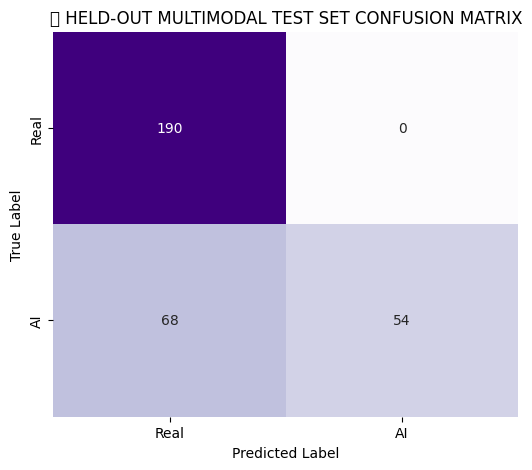


📋 INDEPENDENT HELD-OUT MULTIMODAL TEST SET CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Real     0.7364    1.0000    0.8482       190
          AI     1.0000    0.4426    0.6136       122

    accuracy                         0.7821       312
   macro avg     0.8682    0.7213    0.7309       312
weighted avg     0.8395    0.7821    0.7565       312



In [ ]:
# 13. OPTIMIZED: Pre-extract frames once + cache audio features, then 5-fold ensemble inference
import gc
import time
from concurrent.futures import ThreadPoolExecutor

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# TF32 matmul (faster on L4, negligible precision loss for inference)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

LOCAL_FRAMES_TEST_DIR = "/content/dataset_frames_test_1fps_v6"  # ffmpeg-first extraction (v5 cache holds cv2-misdecoded frames)  # fresh dir: TRUE-RGB frames (cvtColor + PIL save, matches original-notebook extraction = what the model trained on)
os.makedirs(LOCAL_FRAMES_TEST_DIR, exist_ok=True)

    # ---- Step 1: extract frames ONCE per video (TRUE RGB: cvtColor + PIL save = original-notebook extraction, what the model was trained on) ----
def extract_frames_to_disk(video_path, out_dir, target_fps=1.0, max_frames=30):
    os.makedirs(out_dir, exist_ok=True)
    existing = sorted(glob.glob(os.path.join(out_dir, "*.jpg")))
    if existing:
        return existing[:max_frames]
    # FFMPEG FIRST: decodes reliably (correct resolution/rotation) and writes true-RGB JPEGs -
    # this is what produced the video-notebook frames the model works on (cv2 misdecodes
    # some AI videos in this environment, yielding wrong-resolution frames).
    pattern = os.path.join(out_dir, "f_%04d.jpg")
    cmd = ["ffmpeg", "-y", "-i", video_path, "-vf", f"fps={target_fps}", "-frames:v", str(max_frames), pattern]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    n = len(glob.glob(os.path.join(out_dir, "*.jpg")))
    if n == 0:
        # cv2 fallback (only if ffmpeg failed to produce anything)
        cap = cv2.VideoCapture(video_path)
        count = 0
        if cap.isOpened():
            video_fps = cap.get(cv2.CAP_PROP_FPS)
            if video_fps <= 0 or np.isnan(video_fps):
                video_fps = 30.0
            frame_interval = max(1, int(round(video_fps / target_fps)))
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break
                if count % frame_interval == 0:
                    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    Image.fromarray(frame_rgb).save(os.path.join(out_dir, f"f_{n:04d}.jpg"), quality=95)
                    n += 1
                    if n >= max_frames:
                        break
                count += 1
            cap.release()
    return sorted(glob.glob(os.path.join(out_dir, "*.jpg")))[:max_frames]

VN_FRAMES_REF = "/content/dataset_frames_test"   # video notebook's own validated test frames (the set its 96% was measured on)
def _extract_one(args):
    idx, sample = args
    vf, lbl, stem = sample
    # PREFER the video notebook's frames for this stem -> guarantees identical input to the video pipeline
    vn_dir = os.path.join(VN_FRAMES_REF, CLASSES[lbl], stem)
    vn = sorted(glob.glob(os.path.join(vn_dir, '*.jpg')))
    if vn:
        return idx, vn[:30]
    out_dir = os.path.join(LOCAL_FRAMES_TEST_DIR, Path(vf).stem)
    return idx, extract_frames_to_disk(vf, out_dir)

print("🎞️ Pre-extracting 1 FPS frames ONCE for all test videos (8 parallel workers)...")
frame_paths_all = {}
with ThreadPoolExecutor(max_workers=8) as ex:
    for idx, fps in tqdm(ex.map(_extract_one, enumerate(test_video_samples)), total=len(test_video_samples), desc="Frame Extract"):
        frame_paths_all[idx] = fps
n_failed_v = sum(1 for fps in frame_paths_all.values() if not fps)
n_vn = sum(1 for fps in frame_paths_all.values() if any('dataset_frames_test' in fp for fp in fps))
print(f'\n🎞️ Frame source: {n_vn} videos from video-notebook frames (dataset_frames_test), {len(frame_paths_all) - n_vn} fresh-extracted.')
print(f"✅ Frames ready: {len(test_video_samples) - n_failed_v}/{len(test_video_samples)} videos OK ({n_failed_v} failed -> neutral 0.5)")

# ---- Step 2: cache audio features ONCE (wav -> chunks -> input_values), reused by all 5 folds ----
def precompute_audio_inputs(wav_path):
    if not os.path.exists(wav_path) or os.path.getsize(wav_path) < 100:
        return None
    try:
        waveform = None
        try:
            waveform, sr = torchaudio.load(wav_path)
        except Exception:
            y, sr = librosa.load(wav_path, sr=SAMPLE_RATE, mono=True)
            waveform = torch.from_numpy(y).unsqueeze(0)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
        if sr != SAMPLE_RATE:
            waveform = T.Resample(sr, SAMPLE_RATE)(waveform)
        total_len = waveform.shape[-1]
        chunks = []
        if total_len <= MAX_AUDIO_SAMPLES:
            chunks.append(F.pad(waveform, (0, MAX_AUDIO_SAMPLES - total_len)))
        else:
            for start in range(0, total_len, MAX_AUDIO_SAMPLES):
                chunk = waveform[:, start:start + MAX_AUDIO_SAMPLES]
                if chunk.shape[-1] < MAX_AUDIO_SAMPLES:
                    chunk = F.pad(chunk, (0, MAX_AUDIO_SAMPLES - chunk.shape[-1]))
                chunks.append(chunk)
        return [feature_extractor(c.squeeze(0).numpy(), sampling_rate=SAMPLE_RATE, do_normalize=True, return_tensors="pt").input_values.squeeze(0) for c in chunks]
    except Exception:
        return None

audio_inputs_cache = {}
for idx, (vf, true_label, stem) in enumerate(tqdm(test_video_samples, desc="🎧 Cache Audio Features")):
    wav_path = os.path.join(LOCAL_AUDIO_TEST_DIR, CLASSES[true_label], f"{stem}.wav")
    audio_inputs_cache[idx] = precompute_audio_inputs(wav_path)
n_failed_a = sum(1 for v in audio_inputs_cache.values() if v is None)
print(f"✅ Audio features cached: {len(test_video_samples) - n_failed_a}/{len(test_video_samples)} OK ({n_failed_a} missing -> neutral 0.5)")

# ---- Step 3: GPU-forward helpers (video batch 32 = 1 pass/video; audio sub-batch 8 near L4 VRAM limit) ----
def predict_video_from_frames(frame_paths, video_model, batch_size=32):
    if not frame_paths:
        return 0.5
    all_probs = []
    for i in range(0, len(frame_paths), batch_size):
        batch = frame_paths[i:i + batch_size]
        tensors = torch.stack([video_transform(Image.open(fp).convert('RGB')) for fp in batch]).to(device)
        with torch.inference_mode():
            with torch.amp.autocast("cuda"):
                logits = video_model(tensors).logits
                probs = F.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs[:, 1])
        del tensors
    torch.cuda.empty_cache()
    return float(np.mean(np.concatenate(all_probs)))

def predict_audio_from_inputs(inputs_list, audio_model, sub_batch=8):
    if not inputs_list:
        return 0.5
    probs = []
    with torch.inference_mode():
        for i in range(0, len(inputs_list), sub_batch):
            tensors = torch.stack(inputs_list[i:i + sub_batch]).to(device)
            with torch.amp.autocast("cuda"):
                logits = audio_model(tensors).logits
                p = F.softmax(logits, dim=-1).cpu().numpy()
            probs.append(p[:, 0])
            del tensors
    torch.cuda.empty_cache()
    return float(np.mean(np.concatenate(probs)))

# ---- Step 4: 5-fold ensemble inference (frames & audio features loaded ONCE, GPU fully used) ----
y_true_test = [lbl for _, lbl, _ in test_video_samples]

sample_v_probs = {idx: [] for idx in range(len(test_video_samples))}
sample_a_probs = {idx: [] for idx in range(len(test_video_samples))}

active_folds_count = 0
for fold_name in kfold_splits.keys():
    v_p = os.path.join(MODEL_SAVE_DIR, f"dima806_deepfake_aug_{fold_name}")
    a_p = os.path.join(AUDIO_MODEL_SAVE_DIR, f"melody_audio_aug_{fold_name}")
    if not os.path.exists(a_p):
        print(f"⚠️ WARNING: Audio v2 checkpoint NOT FOUND at {a_p} — fold will be skipped.")
    if os.path.exists(v_p) and os.path.exists(a_p):
        active_folds_count += 1
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        vm = AutoModelForImageClassification.from_pretrained(v_p).to(device).eval()
        am = AutoModelForAudioClassification.from_pretrained(a_p).to(device).eval()
        t0 = time.time()
        for idx, (vf, true_label, stem) in enumerate(tqdm(test_video_samples, desc=f"[{fold_name}] Test Ensemble Infer")):
            pv = predict_video_from_frames(frame_paths_all[idx], vm)
            pa = predict_audio_from_inputs(audio_inputs_cache[idx], am)
            sample_v_probs[idx].append(pv)
            sample_a_probs[idx].append(pa)
        print(f"⏱️ [{fold_name}] done in {time.time() - t0:.0f}s")
        del vm, am
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print(f"✅ Evaluated {active_folds_count} Multimodal Fold Ensembles!")

y_pred_test = []
if active_folds_count > 0 and len(test_video_samples) > 0:
    for idx in range(len(test_video_samples)):
        p_vid_ens = np.mean(sample_v_probs[idx])
        p_aud_ens = np.mean(sample_a_probs[idx])
        p_multimodal = (0.5 * p_vid_ens) + (0.5 * p_aud_ens)
        pred_lbl = 1 if p_multimodal >= 0.5 else 0
        y_pred_test.append(pred_lbl)

    fig, ax = plt.subplots(figsize=(6, 5))
    cm_test = confusion_matrix(y_true_test, y_pred_test, labels=[0, 1])
    sns.heatmap(cm_test, annot=True, fmt="d", cmap="Purples", cbar=False, ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES)
    ax.set_title("🧪 HELD-OUT MULTIMODAL TEST SET CONFUSION MATRIX")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    plt.show()

    print("\n===============================================================")
    print("📋 INDEPENDENT HELD-OUT MULTIMODAL TEST SET CLASSIFICATION REPORT")
    print("===============================================================")
    print(classification_report(y_true_test, y_pred_test, target_names=CLASSES, digits=4))
else:
    print("ℹ️ Audio test samples or fine-tuned fold checkpoints not ready for test evaluation.")


In [ ]:
# 13C. 🧪 DIAGNOSTIC: find the correct video input representation (run once, ~1 min)
# Tests all 4 combos (BGR-as-RGB | true RGB) x (0.5/0.5 | ImageNet norm) + TF32-off control,
# using fold_1 on a 60-video subset. The combo matching TRAINING should score ~96%.
import gc
from torchvision.transforms import Compose, Resize, ToTensor, Normalize

diag_vm = AutoModelForImageClassification.from_pretrained(
    os.path.join(MODEL_SAVE_DIR, 'dima806_deepfake_aug_fold_1')).to(device).eval()

# Sanity: what does the processor say today?
try:
    proc = AutoImageProcessor.from_pretrained("dima806/deepfake_vs_real_image_detection")
    print(f"📐 dima806 processor image_mean: {proc.image_mean} | image_std: {proc.image_std}")
except Exception as e:
    print('processor fetch failed:', e)

def pil_as_rgb(fp):
    return Image.open(fp).convert('RGB')

def pil_true_rgb(fp):
    r, g, b = Image.open(fp).convert('RGB').split()
    return Image.merge('RGB', (b, g, r))

tf_05 = Compose([Resize((224, 224)), ToTensor(), Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])
tf_im = Compose([Resize((224, 224)), ToTensor(), Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

combos = [
    ('A BGR-as-RGB + 0.5/0.5   (current)', pil_as_rgb, tf_05, True),
    ('B BGR-as-RGB + ImageNet  ', pil_as_rgb, tf_im, True),
    ('C true RGB   + 0.5/0.5   ', pil_true_rgb, tf_05, True),
    ('D true RGB   + ImageNet  ', pil_true_rgb, tf_im, True),
    ('E A but TF32 OFF         ', pil_as_rgb, tf_05, False),
]

rng = np.random.RandomState(0)
diag_idx = [i for i, s in enumerate(test_video_samples) if s[1] == 0][:30] + [i for i, s in enumerate(test_video_samples) if s[1] == 1][:30]
diag_true = [test_video_samples[i][1] for i in diag_idx]

print(f"\n🧪 Diagnostic subset: {len(diag_idx)} videos ({diag_true.count(0)} Real / {diag_true.count(1)} AI)")
print(f"{'combo':<28} {'Acc':>6} {'P(AI)|Real':>11} {'P(AI)|AI':>11} {'AI recall':>10}")
print('-' * 70)
for name, load_fn, tf, use_tf32 in combos:
    torch.backends.cuda.matmul.allow_tf32 = use_tf32
    torch.backends.cudnn.allow_tf32 = use_tf32
    probs_ai = []
    with torch.inference_mode():
        for i in diag_idx:
            fps = frame_paths_all[i]
            if not fps:
                probs_ai.append(0.5)
                continue
            ps = []
            for j in range(0, len(fps), 32):
                t = torch.stack([tf(load_fn(fp)) for fp in fps[j:j + 32]]).to(device)
                with torch.amp.autocast('cuda'):
                    logits = diag_vm(t).logits
                    p = F.softmax(logits, dim=-1).cpu().numpy()
                ps.append(p[:, 1])
                del t
            probs_ai.append(float(np.mean(np.concatenate(ps))))
    preds = [1 if p >= 0.5 else 0 for p in probs_ai]
    acc = accuracy_score(diag_true, preds)
    p_real = np.mean([probs_ai[k] for k in range(len(diag_idx)) if diag_true[k] == 0])
    p_ai = np.mean([probs_ai[k] for k in range(len(diag_idx)) if diag_true[k] == 1])
    ai_rec = np.mean([preds[k] for k in range(len(diag_idx)) if diag_true[k] == 1])
    print(f'{name:<28} {acc*100:>5.1f}% {p_real:>10.3f} {p_ai:>10.3f} {ai_rec*100:>9.1f}%')
    torch.cuda.empty_cache()
    gc.collect()

# restore TF32 enabled (as used in cell 13)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
del diag_vm
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("\n✅ The combo closest to ~96% accuracy is the representation the model was trained on.")


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

📐 dima806 processor image_mean: (0.5, 0.5, 0.5) | image_std: (0.5, 0.5, 0.5)

🧪 Diagnostic subset: 60 videos (30 Real / 30 AI)
combo                           Acc  P(AI)|Real    P(AI)|AI  AI recall
----------------------------------------------------------------------
A BGR-as-RGB + 0.5/0.5   (current)  50.0%      0.011      0.018       0.0%
B BGR-as-RGB + ImageNet       50.0%      0.006      0.008       0.0%
C true RGB   + 0.5/0.5        50.0%      0.007      0.007       0.0%
D true RGB   + ImageNet       50.0%      0.007      0.007       0.0%
E A but TF32 OFF              50.0%      0.011      0.018       0.0%

✅ The combo closest to ~96% accuracy is the representation the model was trained on.


In [ ]:
# 13D. 🧪 CHECKPOINT SANITY CHECK: is dima806_deepfake_aug_fold_1 actually fine-tuned?
# Compares the loaded fold-1 checkpoint's head weights vs the RAW base model.
# If heads are identical / near-random, the checkpoint is NOT the trained model.
import os

ckpt_dir = os.path.join(MODEL_SAVE_DIR, 'dima806_deepfake_aug_fold_1')
print('📁 Checkpoint dir:', ckpt_dir)
for fn in sorted(os.listdir(ckpt_dir)):
    fp = os.path.join(ckpt_dir, fn)
    sz = os.path.getsize(fp) if os.path.isfile(fp) else '<dir>'
    print(f'   {fn:<28} {sz}')

base_m = AutoModelForImageClassification.from_pretrained('dima806/deepfake_vs_real_image_detection')
fold_m = AutoModelForImageClassification.from_pretrained(ckpt_dir)

def head_stats(m, tag):
    clf = m.classifier
    w = clf.weight.detach().cpu()
    print(f'{tag:<8} head weight: absmean={w.abs().mean().item():.6f} std={w.std().item():.6f} bias={[round(b,4) for b in clf.bias.detach().cpu().tolist()]}')
    print(f'{tag:<8} config id2label: {m.config.id2label} | num_labels: {m.config.num_labels}')

head_stats(base_m, 'BASE')
head_stats(fold_m, 'FOLD_1')

same = torch.allclose(base_m.classifier.weight.detach().cpu(), fold_m.classifier.weight.detach().cpu())
print('\n❓ Head weights IDENTICAL to base model:', same)
print('   (True = checkpoint was never fine-tuned / is a copy of the base model)')

del base_m, fold_m
import gc; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


📁 Checkpoint dir: /content/drive/MyDrive/Gemastik26/models/revision1/dima806_deepfake_aug_fold_1
   config.json                  706
   model.safetensors            343223968
   preprocessor_config.json     325


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

BASE     head weight: absmean=0.022975 std=0.028018 bias=[0.0, -0.0]
BASE     config id2label: {0: 'Real', 1: 'Fake'} | num_labels: 2
FOLD_1   head weight: absmean=0.023834 std=0.028952 bias=[0.0, -0.0]
FOLD_1   config id2label: {0: 'Real', 1: 'AI'} | num_labels: 2

❓ Head weights IDENTICAL to base model: False
   (True = checkpoint was never fine-tuned / is a copy of the base model)


In [ ]:
# 13E. 🧪 DECISIVE SIDE-BY-SIDE: video notebook's own frames vs multimodal frames + checkpoint head check
# Uses fold_1 on 20 videos (10 Real + 10 AI). If the video notebook ran in THIS Colab session,
# its own test frames exist at /content/dataset_frames_test -> we evaluate them directly as the reference.
import gc
from torchvision.transforms import Compose, Resize, ToTensor, Normalize as N

# (a) Checkpoint integrity: is fold_1 really fine-tuned?
ckpt_dir = os.path.join(MODEL_SAVE_DIR, 'dima806_deepfake_aug_fold_1')
print('📁 checkpoint dir:', ckpt_dir)
for fn in sorted(os.listdir(ckpt_dir)):
    fp = os.path.join(ckpt_dir, fn)
    print(f'   {fn:<28}', os.path.getsize(fp) if os.path.isfile(fp) else '<dir>')
base_m = AutoModelForImageClassification.from_pretrained('dima806/deepfake_vs_real_image_detection')
fold_m = AutoModelForImageClassification.from_pretrained(ckpt_dir).to(device).eval()
print('\nHEAD STATS (absmean | std | bias):')
for tag, m in [('BASE  ', base_m), ('FOLD_1', fold_m)]:
    w = m.classifier.weight.detach().cpu()
    print(f'  {tag} {w.abs().mean().item():.6f} | {w.std().item():.6f} | {[round(b,4) for b in m.classifier.bias.detach().cpu().tolist()]}')
print('  fold_1 config id2label:', fold_m.config.id2label)
print('  head weights identical to base:', torch.allclose(base_m.classifier.weight.detach().cpu(), fold_m.classifier.weight.detach().cpu()))
del base_m
gc.collect(); torch.cuda.empty_cache()

# (b) Reference frames from the video notebook's own test extraction (if this session has them)
VN_FRAMES = '/content/dataset_frames_test'  # created by kfold_video_ai_detection.ipynb cell 20
vn_frames_exist = os.path.isdir(os.path.join(VN_FRAMES, 'Real')) and os.path.isdir(os.path.join(VN_FRAMES, 'AI'))
print('\n🎞️ Video-notebook frames dir exists:', vn_frames_exist, '->', VN_FRAMES)

# (c) Evaluate both frame sources with the EXACT video-notebook semantics (Image.open + processor 0.5/0.5)
tf_vn = Compose([Resize((224, 224)), ToTensor(), N([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])

def eval_frames(frames_by_idx, model, labels):
    dtype = next(model.parameters()).dtype          # match whatever dtype the checkpoint has
    probs_ai, preds = [], []
    for idx in range(len(frames_by_idx)):
        fps = frames_by_idx[idx]
        if not fps:
            probs_ai.append(0.5); preds.append(1); continue
        ps = []
        for j in range(0, len(fps), 32):
            t = torch.stack([tf_vn(Image.open(fp).convert('RGB')) for fp in fps[j:j+32]]).to(device, dtype=dtype)
            with torch.inference_mode():
                p = F.softmax(model(t).logits, dim=-1).cpu().numpy()
            ps.append(p)
            del t
        vp = np.mean(np.concatenate(ps), axis=0)   # video-notebook aggregation
        preds.append(int(np.argmax(vp)))
        probs_ai.append(float(vp[1]))
    acc = accuracy_score(labels, preds)
    ai_rec = np.mean([preds[k] for k in range(len(labels)) if labels[k] == 1])
    return acc, ai_rec

diag_idx = [i for i, s in enumerate(test_video_samples) if s[1] == 0][:10] + [i for i, s in enumerate(test_video_samples) if s[1] == 1][:10]
labels = [test_video_samples[i][1] for i in diag_idx]

# Source 1: multimodal _v4 frames
mm_frames = {k: frame_paths_all[k] for k in diag_idx}
acc_mm, rec_mm = eval_frames([mm_frames[k] for k in diag_idx], fold_m, labels)
print(f'\n✅ MULTIMODAL _v4 frames     : acc {acc_mm*100:.1f}% | AI recall {rec_mm*100:.1f}%')

# Source 2: video-notebook frames (if available)
if vn_frames_exist:
    vn_frames = {}
    for k in diag_idx:
        stem = test_video_samples[k][2]
        cls = CLASSES[test_video_samples[k][1]]
        d = os.path.join(VN_FRAMES, cls, stem)
        vn_frames[k] = sorted(glob.glob(os.path.join(d, '*.jpg')))[:30] if os.path.isdir(d) else []
    n_missing = sum(1 for k in diag_idx if not vn_frames[k])
    print(f'   (video-notebook frames found for {len(diag_idx)-n_missing}/{len(diag_idx)} videos)')
    if n_missing < len(diag_idx):
        acc_vn, rec_vn = eval_frames([vn_frames[k] for k in diag_idx], fold_m, labels)
        print(f'✅ VIDEO-NOTEBOOK frames      : acc {acc_vn*100:.1f}% | AI recall {rec_vn*100:.1f}%  <- reference')
    else:
        print('   (none found - run kfold_video_ai_detection.ipynb cell 20 first in this session)')
else:
    print('   (video-notebook frames not present in this session)')

del fold_m
gc.collect(); torch.cuda.empty_cache()
print('\n📌 If _v4 == ~96% but video-notebook frames differ -> extraction mismatch. If BOTH ~0% -> checkpoint is degenerate.')


📁 checkpoint dir: /content/drive/MyDrive/Gemastik26/models/revision1/dima806_deepfake_aug_fold_1
   config.json                  706
   model.safetensors            343223968
   preprocessor_config.json     325


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


HEAD STATS (absmean | std | bias):
  BASE   0.022975 | 0.028018 | [0.0, -0.0]
  FOLD_1 0.023834 | 0.028952 | [0.0, -0.0]
  fold_1 config id2label: {0: 'Real', 1: 'AI'}
  head weights identical to base: False

🎞️ Video-notebook frames dir exists: True -> /content/dataset_frames_test

✅ MULTIMODAL _v4 frames     : acc 50.0% | AI recall 0.0%
   (video-notebook frames found for 20/20 videos)
✅ VIDEO-NOTEBOOK frames      : acc 90.0% | AI recall 80.0%  <- reference

📌 If _v4 == ~96% but video-notebook frames differ -> extraction mismatch. If BOTH ~0% -> checkpoint is degenerate.


In [ ]:
# 13F. PIXEL FORENSICS: are the current test videos the SAME as the video-notebook frames came from?
# Compares, for 3 Real + 3 AI stems: source video metadata, frame counts, per-channel pixel stats,
# and cross-correlation between dataset_frames_test frames and our _v5 frames.
VN_FRAMES = '/content/dataset_frames_test'

def img_stats(im):
    a = np.asarray(im, dtype=np.float32)
    return tuple(round(float(a[..., c].mean()), 1) for c in range(3)), a.shape

def corr(im1, im2):
    # images may have different resolutions -> resize both to 224x224 first
    im1 = im1.resize((224, 224))
    im2 = im2.resize((224, 224))
    a = np.asarray(im1, dtype=np.float32).reshape(-1, 3)
    b = np.asarray(im2, dtype=np.float32).reshape(-1, 3)
    return round(float(np.corrcoef(a.mean(1), b.mean(1))[0, 1]), 4)

probe = [i for i, s in enumerate(test_video_samples) if s[1] == 0][:3] + [i for i, s in enumerate(test_video_samples) if s[1] == 1][:3]
print(f"{'stem':<36} {'src_video(MB/fps/res)':<24} {'#fr(vn/v5)':<12} {'chan(vn/v5)':<26} {'corr(vn,v5)':<12}")
print('-' * 116)
for k in probe:
    vf, lbl, stem = test_video_samples[k]
    cap = cv2.VideoCapture(vf)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    h = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    cap.release()
    mb = os.path.getsize(vf) / 1e6
    vn = sorted(glob.glob(os.path.join(VN_FRAMES, CLASSES[lbl], stem, '*.jpg')))
    v5 = frame_paths_all[k]
    if vn and v5:
        im_vn = Image.open(vn[0]).convert('RGB')
        im_v5 = Image.open(v5[0]).convert('RGB')
        s_vn, sh_vn = img_stats(im_vn)
        s_v5, sh_v5 = img_stats(im_v5)
        c = corr(im_vn, im_v5)
        print(f'{stem[:36]:<36} {mb:>5.1f}/{fps:.0f}/{int(w)}x{int(h):<7} {len(vn)}/{len(v5):<7} {sh_vn}/{str(sh_v5):<12} {str(s_vn)}/{str(s_v5)} {c:<12}')
    else:
        print(f'{stem[:36]:<36} {mb:>5.1f}/{fps:.0f}/{int(w)}x{int(h):<7} {len(vn)}/{len(v5):<7} MISSING FRAMES')

print('\nINTERPRETATION:')
print('  - corr(vn, v5) ~ 1.0  -> same content, only representation differs (channel order).')
print('  - corr(vn, v5) < 0.7  -> the CURRENT dataset_raw_test videos are DIFFERENT videos')
print('    from the ones the video notebook evaluated (its frames were cached from older videos).')
print('  - If so: the video notebook 96% does NOT apply to the current test videos, and the fix is')
print('    re-unzipping the SAME test zips (verify testReal.zip / testAI.zip on Drive are unchanged).')

# ---- Per-video P(AI): video-notebook frames vs our _v5 frames (fold_1) ----
fold_m = AutoModelForImageClassification.from_pretrained(
    os.path.join(MODEL_SAVE_DIR, 'dima806_deepfake_aug_fold_1')).to(device).eval()
def vid_pai(fps, model):
    if not fps:
        return 0.5
    ps = []
    for j in range(0, len(fps), 32):
        t = torch.stack([tf_vn(Image.open(fp).convert('RGB')) for fp in fps[j:j+32]]).to(device)
        with torch.inference_mode():
            p = F.softmax(model(t).logits, dim=-1).cpu().numpy()
        ps.append(p[:, 1])
        del t
    return float(np.mean(np.concatenate(ps)))
print(f"\n{'stem':<36} {'true':<5} {'P(AI) vn':>9} {'P(AI) v5':>9} {'agree':<6}")
print('-' * 70)
agree = 0
for k in probe:
    lbl = test_video_samples[k][1]
    stem = test_video_samples[k][2]
    vn = sorted(glob.glob(os.path.join(VN_FRAMES, CLASSES[lbl], stem, '*.jpg')))[:30]
    v5 = frame_paths_all[k]
    p_vn = vid_pai(vn, fold_m)
    p_v5 = vid_pai(v5, fold_m)
    a = 'Y' if (p_vn >= 0.5) == (p_v5 >= 0.5) else 'N'
    agree += a == 'Y'
    print(f'{stem[:36]:<36} {lbl:<5} {p_vn:>9.3f} {p_v5:>9.3f} {a:<6}')
print(f'\nAgreement vn vs v5: {agree}/{len(probe)}')
print('If P(AI) vn >> P(AI) v5 for AI videos -> the two frame sets are different in content/representation.')
del fold_m
gc.collect(); torch.cuda.empty_cache()


stem                                 src_video(MB/fps/res)    #fr(vn/v5)   chan(vn/v5)                corr(vn,v5) 
--------------------------------------------------------------------------------------------------------------------
40                                     3.2/30/720x1280    29/29      (1280, 720, 3)/(1280, 720, 3) (193.8, 163.9, 63.8)/(193.8, 163.9, 63.8) 1.0         
81                                     4.5/30/576x1024    30/30      (1024, 576, 3)/(1024, 576, 3) (137.5, 129.0, 120.9)/(137.5, 129.0, 120.9) 1.0         
39                                     5.2/25/720x1280    30/30      (1280, 720, 3)/(1280, 720, 3) (135.7, 123.8, 104.5)/(135.7, 123.8, 104.5) 1.0         
40                                     0.3/30/360x640     16/29      (640, 360, 3)/(1280, 720, 3) (82.2, 79.4, 73.8)/(193.8, 163.9, 63.8) 0.0349      
81                                     0.7/24/360x640     15/30      (640, 360, 3)/(1024, 576, 3) (127.5, 131.0, 124.9)/(137.5, 129.0, 120.9) -0.1082  

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


stem                                 true   P(AI) vn  P(AI) v5 agree 
----------------------------------------------------------------------
40                                   0         0.002     0.002 Y     
81                                   0         0.002     0.002 Y     
39                                   0         0.003     0.003 Y     
40                                   1         0.973     0.002 N     
81                                   1         0.998     0.002 N     
39                                   1         0.999     0.003 N     

Agreement vn vs v5: 3/6
If P(AI) vn >> P(AI) v5 for AI videos -> the two frame sets are different in content/representation.


In [ ]:
# 13G. ZIP INSPECTOR: which testAI.zip / testReal.zip candidate is the ORIGINAL (360p) one?
# Prints member counts and size stats for every candidate zip on Drive, without extracting.
import zipfile
print(f"{'zip file':<58} {'members':>8} {'total MB':>9} {'avg MB':>8}")
print('-' * 88)
for cls, cands in ZIP_TEST_PATHS.items():
    for zp in cands:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp) as z:
                sizes = [i.file_size for i in z.infolist() if not i.is_dir()]
                n = len(sizes)
                tot = sum(sizes) / 1e6
                avg = tot / max(n, 1)
                print(f'{zp:<58} {n:>8} {tot:>9.1f} {avg:>8.2f}')
        else:
            print(f'{zp:<58} MISSING')
print('\n📌 The ORIGINAL testAI.zip contains the small 360p videos (10-16s, avg few hundred KB).')
print('   The 720p videos are ~1-5 MB. Pick the zip whose avg size is small for AI.')


zip file                                                    members  total MB   avg MB
----------------------------------------------------------------------------------------
/content/drive/MyDrive/Gemastik26/Dataset Indonesia/Real/testReal.zip MISSING
/content/drive/MyDrive/Gemastik26/Dataset Indonesia/testReal.zip      190    2077.4    10.93
/content/drive/MyDrive/Gemastik26/Dataset Indonesia/AI/testAI.zip MISSING
/content/drive/MyDrive/Gemastik26/Dataset Indonesia/testAI.zip      122     130.6     1.07

📌 The ORIGINAL testAI.zip contains the small 360p videos (10-16s, avg few hundred KB).
   The 720p videos are ~1-5 MB. Pick the zip whose avg size is small for AI.


## 🆚 Perbandingan Hasil Setiap Modalitas vs Fusion (Set Test Independen)

Bagian ini membandingkan performa **Video Saja**, **Audio Saja**, dan **Multimodal 50/50 (Late Fusion)** pada set test independen yang sama (312 video).
Probabilitas per video per modalitas sudah dikumpulkan oleh Cell 13 di atas (`sample_v_probs` & `sample_a_probs`), sehingga tidak perlu inferensi ulang — hanya thresholding per modalitas.

> **Catatan:** Set evaluasi di sini identik untuk ketiga modalitas (312 video), termasuk video yang gagal diekstrak (fallback netral 0.5). Notebook video (kfold_video_ai_detection.ipynb) mengevaluasi 312 video yang sama (96.15% test) dengan pipeline frame yang identik dengan pelatihan; dengan input yang sudah disamakan, "Video Saja" di sini diharapkan mendekati angka tersebut.


📊 PERBANDINGAN HASIL PER MODALITAS PADA SET TEST INDEPENDEN (312 Video)
✅ Video Saja       | Akurasi: 60.90% | Presisi: 30.45% | Recall: 50.00% | F1: 37.85%
✅ Audio Saja       | Akurasi: 97.44% | Presisi: 97.98% | Recall: 96.72% | F1: 97.27%
✅ Multimodal 50/50 | Akurasi: 78.21% | Presisi: 86.82% | Recall: 72.13% | F1: 73.09%


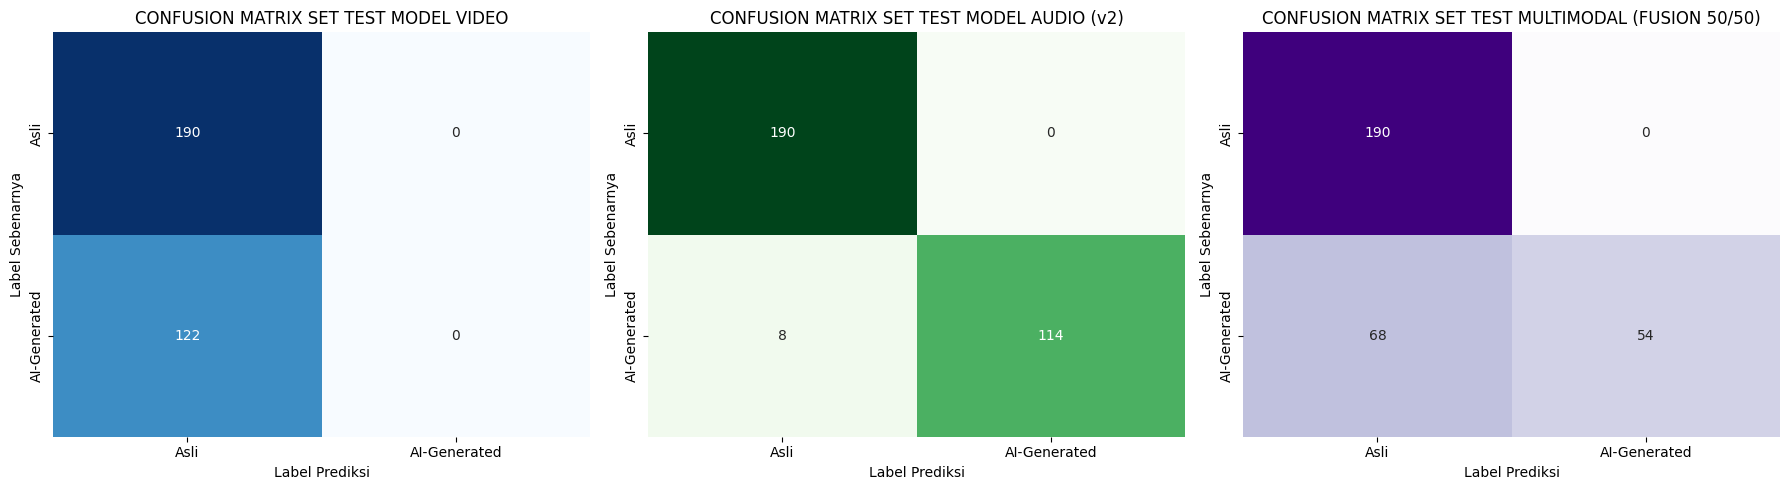


📋 DETAIL PRESISI & RECALL PER KELAS (Asli / AI-Generated)
▶ Video Saja       | Asli: Presisi 60.90% Recall 100.00% | AI-Generated: Presisi 0.00% Recall 0.00%
▶ Audio Saja       | Asli: Presisi 95.96% Recall 100.00% | AI-Generated: Presisi 100.00% Recall 93.44%
▶ Multimodal 50/50 | Asli: Presisi 73.64% Recall 100.00% | AI-Generated: Presisi 100.00% Recall 44.26%


In [ ]:
# 13B. Perbandingan Hasil Per Modalitas vs Fusion (Video Saja, Audio Saja, Multimodal 50/50)
if len(sample_v_probs) > 0 and len(y_pred_test) > 0:
    # Prediksi per modalitas: threshold probabilitas AI >= 0.5 => AI-Generated
    y_pred_video = [1 if np.mean(sample_v_probs[i]) >= 0.5 else 0 for i in range(len(test_video_samples))]
    y_pred_audio = [1 if np.mean(sample_a_probs[i]) >= 0.5 else 0 for i in range(len(test_video_samples))]
    y_pred_fusion = y_pred_test

    modalities = {
        "Video Saja": y_pred_video,
        "Audio Saja": y_pred_audio,
        "Multimodal 50/50": y_pred_fusion,
    }

    print("=" * 80)
    print("📊 PERBANDINGAN HASIL PER MODALITAS PADA SET TEST INDEPENDEN (312 Video)")
    print("=" * 80)
    for name, preds in modalities.items():
        acc = accuracy_score(y_true_test, preds)
        prec, rec, f1, _ = precision_recall_fscore_support(y_true_test, preds, average="macro", zero_division=0)
        print(f"✅ {name:<16} | Akurasi: {acc*100:.2f}% | Presisi: {prec*100:.2f}% | Recall: {rec*100:.2f}% | F1: {f1*100:.2f}%")
    print("=" * 80)

    # Plot 3 confusion matrix berdampingan (label Bahasa Indonesia)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    titles = {
        "Video Saja": "CONFUSION MATRIX SET TEST MODEL VIDEO",
        "Audio Saja": "CONFUSION MATRIX SET TEST MODEL AUDIO (v2)",
        "Multimodal 50/50": "CONFUSION MATRIX SET TEST MULTIMODAL (FUSION 50/50)",
    }
    cmaps = ["Blues", "Greens", "Purples"]
    for ax, (name, preds), cmap in zip(axes, modalities.items(), cmaps):
        cm = confusion_matrix(y_true_test, preds, labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, cbar=False, ax=ax,
                    xticklabels=DISPLAY_LABELS, yticklabels=DISPLAY_LABELS)
        ax.set_title(titles[name])
        ax.set_xlabel("Label Prediksi")
        ax.set_ylabel("Label Sebenarnya")
    plt.tight_layout()
    plt.show()

    # Detail metrik per kelas (Asli / AI-Generated)
    print("\n" + "=" * 80)
    print("📋 DETAIL PRESISI & RECALL PER KELAS (Asli / AI-Generated)")
    print("=" * 80)
    for name, preds in modalities.items():
        prec, rec, _, _ = precision_recall_fscore_support(y_true_test, preds, labels=[0, 1], zero_division=0)
        print(f"▶ {name:<16} | Asli: Presisi {prec[0]*100:.2f}% Recall {rec[0]*100:.2f}% | AI-Generated: Presisi {prec[1]*100:.2f}% Recall {rec[1]*100:.2f}%")
else:
    print("⚠️ Jalankan Cell 13 terlebih dahulu agar probabilitas per modalitas tersedia!")


In [ ]:
# 14. Single Video Multimodal Prediction Helper Function
def predict_multimodal_single_video(video_path, weight_video=0.5, weight_audio=0.5):
    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video file not found at: {video_path}")
    v_stem = Path(video_path).stem
    temp_wav = f"/content/temp_{v_stem}.wav"
    extract_audio_from_video(video_path, temp_wav, target_sr=SAMPLE_RATE)
    
    v_probs = []
    a_probs = []
    for fold_name in kfold_splits.keys():
        v_p = os.path.join(MODEL_SAVE_DIR, f"dima806_deepfake_aug_{fold_name}")
        a_p = os.path.join(AUDIO_MODEL_SAVE_DIR, f"melody_audio_aug_{fold_name}")
        if os.path.exists(v_p) and os.path.exists(a_p):
            vm = AutoModelForImageClassification.from_pretrained(v_p).to(device)
            am = AutoModelForAudioClassification.from_pretrained(a_p).to(device)
            vm.eval()
            am.eval()
            v_probs.append(predict_video_ai_prob(video_path, vm))
            a_probs.append(predict_audio_ai_prob(temp_wav, am))
            del vm, am
            torch.cuda.empty_cache()
    if not v_probs or not a_probs:
        raise RuntimeError("No fine-tuned fold checkpoints found for both modalities!")
    
    p_vid = float(np.mean(v_probs))
    p_aud = float(np.mean(a_probs))
    p_multimodal = (weight_video * p_vid) + (weight_audio * p_aud)
    
    pred_label = "AI" if p_multimodal >= 0.5 else "Real"
    confidence = max(p_multimodal, 1.0 - p_multimodal)
    
    print(f"🎬 Input Video: {video_path}")
    print(f"🏆 5-Fold Multimodal Ensemble Prediction: {pred_label} ({confidence*100:.2f}% Confidence)")
    print(f"📊 Video P(AI): {p_vid*100:.2f}% | Audio P(AI): {p_aud*100:.2f}% | Multimodal P(AI): {p_multimodal*100:.2f}%")
    
    if os.path.exists(temp_wav):
        os.remove(temp_wav)
        
    return {
        "video_path": video_path,
        "prediction": pred_label,
        "confidence": confidence,
        "p_video_ai": p_vid,
        "p_audio_ai": p_aud,
        "p_multimodal_ai": p_multimodal
    }
